<a href="https://colab.research.google.com/github/ksjones21-bit/hospital-admissions-trends/blob/main/hospital_admissions_trends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hospital Admissions Trends Analysis

This project analyzes hospital admissions data to identify trends over time and compare admission types. The goal is to explore patterns in hospital utilization using patient admission records.

In [1]:
import pandas as pd

df = pd.read_csv("/content/healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## Data Loading

This step loads the healthcare dataset into pandas so it can be analyzed.

In [3]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])

In [4]:
df["Admission Month"] = df["Date of Admission"].dt.to_period("M").astype(str)
df[["Date of Admission", "Admission Month"]].head()

,Date of Admission,Admission Month
0,2024-01-31,2024-01
1,2019-08-20,2019-08
2,2022-09-22,2022-09
3,2020-11-18,2020-11
4,2022-09-19,2022-09


## Admissions by Month

This analysis counts the number of hospital admissions by month to identify trends over time.

In [5]:
admissions_by_month = df["Admission Month"].value_counts().sort_index()
admissions_by_month

,count
Admission Month,
2019-05,686
2019-06,907
2019-07,957
2019-08,1001
2019-09,936
...,...
2024-01,909
2024-02,880
2024-03,906


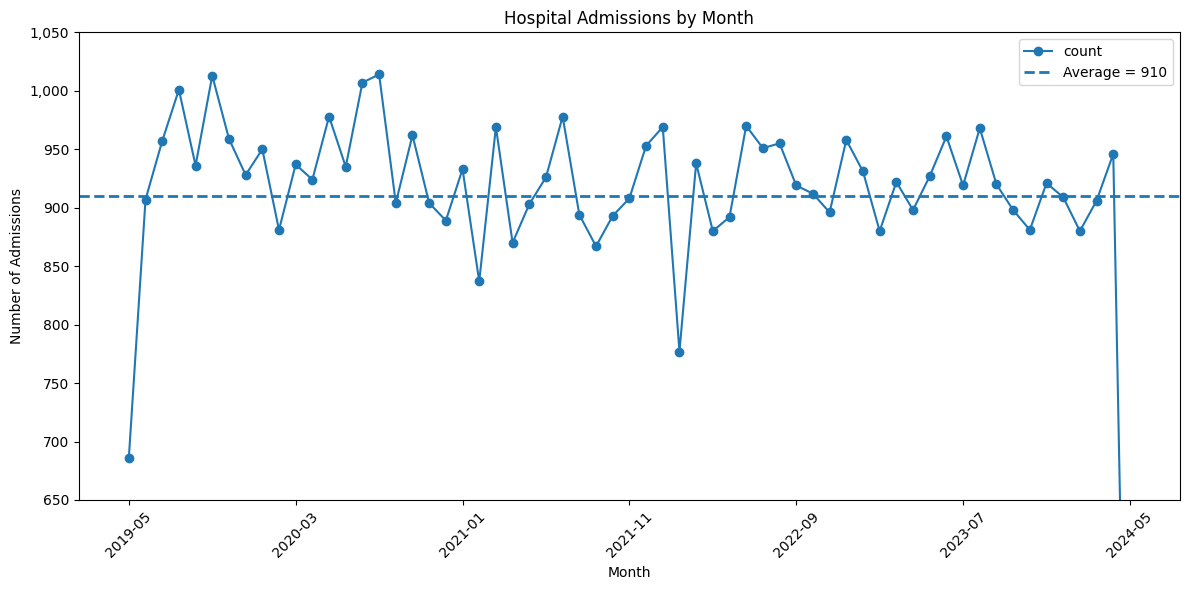

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

monthly_avg = admissions_by_month.mean()

plt.figure(figsize=(12,6))

ax = admissions_by_month.plot(kind="line", marker="o")

plt.axhline(monthly_avg, linestyle="--", linewidth=2, label=f"Average = {monthly_avg:.0f}")

plt.title("Hospital Admissions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)

plt.ylim(650, 1050)
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.legend()
plt.tight_layout()

plt.savefig("admissions_by_month.png")

plt.show()

### Insight

This chart shows how hospital admissions changed over time in the dataset. Trend analysis can help healthcare organizations understand patient volume patterns and support capacity planning.

### Insight

This chart shows how hospital admissions changed over time in the dataset. Trend analysis can help healthcare organizations understand patient volume patterns and support capacity planning.

## Admissions by Admission Type

This analysis compares the number of admissions across emergency, urgent, and elective categories.

In [10]:
admission_type_counts = df["Admission Type"].value_counts()

admission_type_counts.map(lambda x: f"{x:,}")

,count
Admission Type,
Elective,"18,655"
Urgent,"18,576"
Emergency,"18,269"


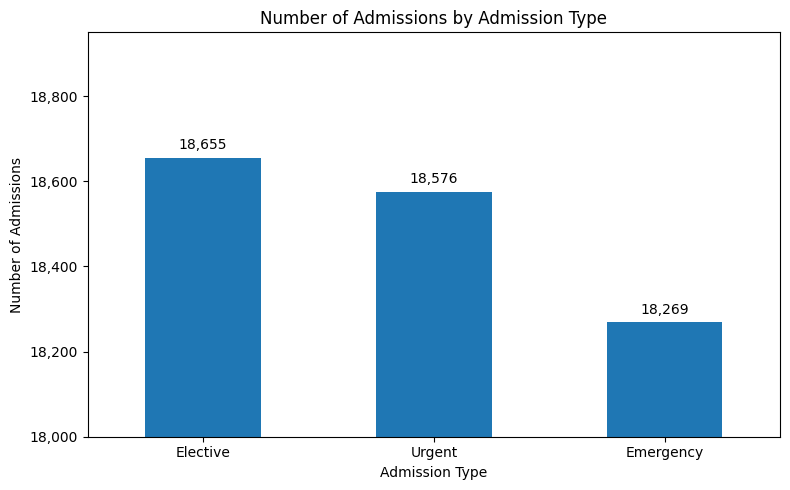

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.figure(figsize=(8,5))

ax = admission_type_counts.plot(kind="bar")

plt.title("Number of Admissions by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=0)

plt.ylim(18000, 18950)

plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

for i, value in enumerate(admission_type_counts):
    ax.text(i, value + 20, f"{value:,}", ha='center')

plt.tight_layout()
plt.savefig("admissions_by_type.png")
plt.show()

### Insight

This visualization compares the volume of admissions across admission types. Understanding which type occurs most often can help healthcare systems plan staffing, workflows, and patient intake processes.

## Project Summary

This analysis explored hospital admissions patterns using patient admission data.

Key observations from the analysis include:

- Monthly hospital admissions remain relatively stable over time, with most months clustering around the overall average.
- Admission volumes are fairly evenly distributed across elective, urgent, and emergency categories.
- No strong seasonality patterns appear in the dataset, suggesting consistent patient intake over the observed period.

These findings demonstrate how exploratory data analysis can be used to evaluate operational trends in healthcare systems and support capacity planning.